In [1]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from matplotlib import pyplot as plt

Data Preparation/Visualization
For the next step in the walkthrough, I will beimporting the MNIST dataset from Keras. There are a few preprocessing steps that are required before we can visualize the data. They will follow the order below:

Split the data between testing and training sets
Scale images to the 0 to 1 range
Making sure the images have the correct input shape (each input is in the form of a 28x28 sized pixel)
Converting class vectors to binary class matrices
Splitting into test/train data

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 [==============================] - 3s 0us/step


Scaling the images

In this section, the pixel values for each image in the dataset are between the range of 0 and 255. These values are associated with values in the range from black to white. So in order to scale them properly, the values will have to first be converted to floats, then divided by 255.

In [ ]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

Correcting input shape

In [ ]:
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")

Converting predicted value to binary class matrices

Keras’s Utility library can be very helpful in performing functions on Numpy arrays. Our desired outcome is go from an array to a matrix. So a prediction of [2] would be represented as [0,0,1,0,0,0,0,0,0,0]. The number classes in this case is 10, which represents all the possible values from 0 to 9 (inclusively).

In [ ]:
num_classes = 10
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print(y_train.shape)

Visualizing the data
For the visualization, I will be plotting the first 9 images in the dataset to give an idea of what I will be predicting. Since this is taking the first 9 values, not all the possible classes will be shown.

In [ ]:
for i in range(9):
 # define subplot
 plt.subplot(330 + 1 + i)
 # plot raw pixel data
 plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))
# show the figure
plt.show()

Building the model
There are some key factors in defining our simple convolutional neural network for this problem. These models are a specialized type of neural network designed to work for two dimensional image data. These models have two main aspects: the feature extraction front end and the classifier backend. The goal of the CNN is to reduce the inputted images into a form which is very easy to process, without losing some features which are crucial for getting an accurate prediction. 


In [5]:
# Keras (TensorFlow) + Python 3
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from matplotlib import pyplot as plt


In [18]:
# Split into train / test sets
(x_train, y_train), (x_test, y_test) = \
    keras.datasets.mnist.load_data()
 
# Scale pixel values 0-255 -> 0-1
x_train = x_train.astype("float32") / 255
x_test  = x_test.astype("float32") / 255


In [19]:
#Add a channel dimension -> (28, 28, 1)
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)
 
# One-hot encode the labels (10 classes)
y_train = keras.utils.to_categorical(y_train, 10)
y_test  = keras.utils.to_categorical(y_test, 10)


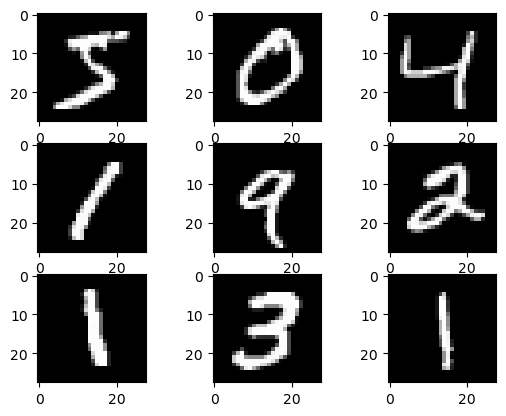

In [20]:
# Plot the first 9 training images
for i in range(9):
    plt.subplot(330 + 1 + i)
    plt.imshow(x_train[i],
               cmap=plt.get_cmap('gray'))
plt.show()


In [ ]:
model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),#there are total 32 (3*3) matrix
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),#reduce 2d to 1 d
    layers.Dropout(0.5),#50n\% of the neuron will be dropout
    layers.Dense(10, activation="softmax"),
])


In [22]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 13, 13, 32)       0         
 2D)                                                             
                                                                 
 conv2d_3 (Conv2D)           (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 1600)              0         
                                                                 
 dropout_1 (Dropout)         (None, 1600)             

In [23]:
model.compile(loss="categorical_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])
 
history=model.fit(x_train, y_train,
          batch_size=128, epochs=15,
          validation_split=0.1)


Epoch 1/15
422/422 [==============================] - 11s 25ms/step - loss: 0.3608 - accuracy: 0.8930 - val_loss: 0.0814 - val_accuracy: 0.9778
Epoch 2/15
422/422 [==============================] - 11s 26ms/step - loss: 0.1112 - accuracy: 0.9661 - val_loss: 0.0578 - val_accuracy: 0.9843
Epoch 3/15
422/422 [==============================] - 11s 26ms/step - loss: 0.0851 - accuracy: 0.9741 - val_loss: 0.0493 - val_accuracy: 0.9857
Epoch 4/15
422/422 [==============================] - 11s 26ms/step - loss: 0.0695 - accuracy: 0.9788 - val_loss: 0.0403 - val_accuracy: 0.9893
Epoch 5/15
422/422 [==============================] - 11s 26ms/step - loss: 0.0619 - accuracy: 0.9804 - val_loss: 0.0357 - val_accuracy: 0.9902
Epoch 6/15
422/422 [==============================] - 11s 26ms/step - loss: 0.0567 - accuracy: 0.9828 - val_loss: 0.0353 - val_accuracy: 0.9907
Epoch 7/15
422/422 [==============================] - 11s 26ms/step - loss: 0.0497 - accuracy: 0.9850 - val_loss: 0.0336 - val_accuracy:

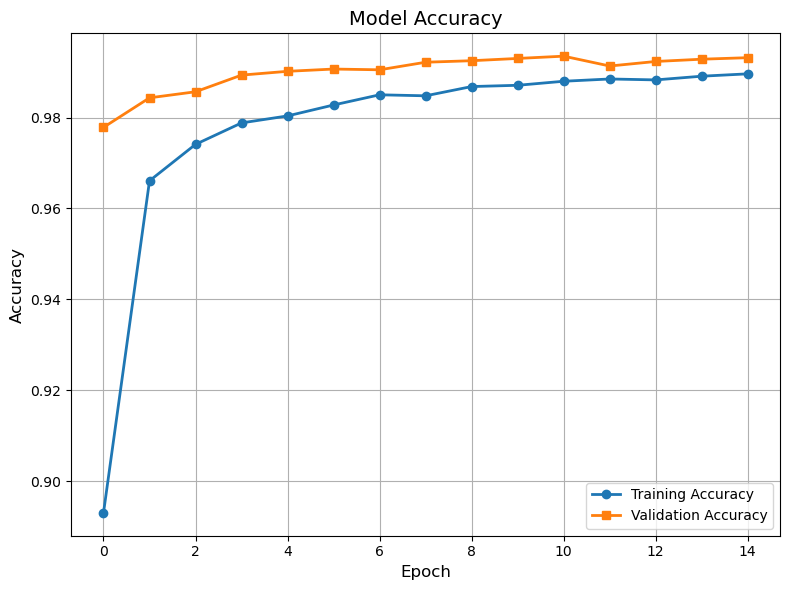

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.plot(history.history['accuracy'], marker='o', linewidth=2, label='Training Accuracy')
plt.plot(history.history['val_accuracy'], marker='s', linewidth=2, label='Validation Accuracy')

plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()

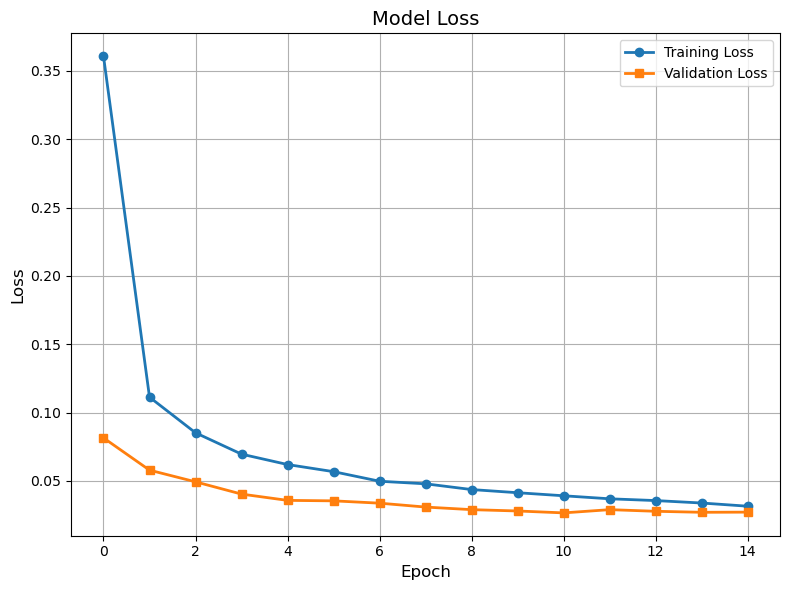

In [26]:
plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], marker='o', linewidth=2, label='Training Loss')
plt.plot(history.history['val_loss'], marker='s', linewidth=2, label='Validation Loss')

plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('Loss_Curve.png', dpi=600, bbox_inches='tight')

plt.show()

In [28]:
score = model.evaluate(x_test, y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])


313/313 [==============================] - 1s 4ms/step - loss: 0.0241 - accuracy: 0.9924
Test loss: 0.024118740111589432
Test accuracy: 0.9923999905586243


In [30]:
plt.figure(figsize=(8,6))
plt.plot(score.score['accuracy'], marker='o', linewidth=2, label='Training Accuracy')

plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()

AttributeError: 'list' object has no attribute 'score'

<Figure size 800x600 with 0 Axes>

313/313 [==============================] - 1s 4ms/step


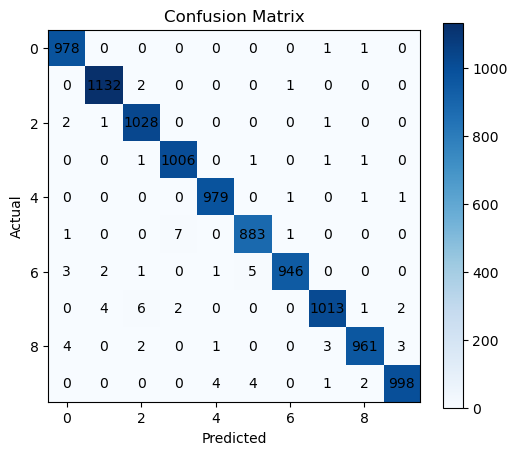

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Predict on test set
y_pred = model.predict(x_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Display values inside matrix
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center')

plt.show()